In [5]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from coffea import util
from coffea.processor import accumulate
import os
import re
import pandas as pd
import hist
import matplotlib as mpl
import mplhep
import sys
import hist
import hist.intervals

sys.path.append("../analysisTools/")
import plotTools as ptools
import utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
f_sig = "../coffea/AllInOne_2022/AllInOne.coffea"

#Nested Dictionary:
sig_histo = util.load(f_sig) [0]
sig_histo.keys()

dict_keys(['gen_dR', 'dR_gen_GED_GED', 'dR_gen_Lpt_Lpt', 'dR_gen_GED_Lpt', 'dR_gen_Lpt_GED', 'gen_ele_pt', 'gen_ele_vxy1', 'pT_genElePos_GED', 'pT_genElePos_Lpt', 'vxy_genElePos_GED', 'vxy_genElePos_Lpt', 'pT_genElePos_Lpt_Noxclean', 'vxy_genElePos_Lpt_Noxclean', 'cutDesc', 'cutflow', 'cutflow_cts', 'cutflow_nevts', 'cutflow_vtx_matched'])

Saved: ./plots/signal_2018/gen_ele_vxy10_m110.png
Saved: ./plots/signal_2018/gen_ele_vxy10_m110.png
Saved: ./plots/signal_2018/gen_ele_vxy10_m110.png
average= [708.         976.         831.         658.         512.66666667
 419.33333333 299.33333333 240.33333333 201.         154.33333333
 133.         114.33333333 100.66666667  75.33333333  65.66666667
  57.66666667  50.          53.66666667  38.66666667  38.33333333
  40.33333333  30.          24.66666667  22.66666667  24.33333333
  26.          22.33333333  18.          21.          19.66666667
  20.                  nan  12.                  nan   7.
   3.66666667          nan          nan          nan          nan
          nan          nan          nan          nan          nan
          nan          nan          nan          nan          nan]


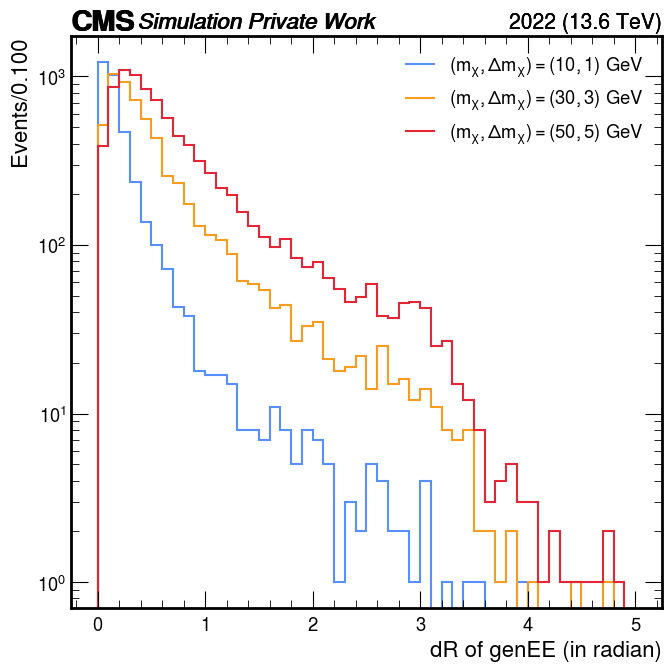

In [21]:
fig, ax = plt.subplots(figsize=(7,7))

delta =0.1
ctau =10

# Plot settings
plot_dict = {
    'variable':'gen_dR',
    'cut': 'cut3',
    'year': 2022
}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': False,
    'doYerr': False, 
    'xlabel': "dR of genEE (in radian)",   # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2018',
    'outName': f'gen_ele_vxy10_m110.png'
}



#signal points
m1s=[10,30,50]
delta =0.1
ctau =10


results = [
    ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict)
    
    for m1 in m1s
]

counts, edges = zip(*results)

counts = np.array(counts)     # shape: (n_m1, n_bins)
edges  = np.array(edges)      # shape: (n_m1, n_edges)

# counts, edges = ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict)


mask = counts != 0

bins_x = (edges[:,:-1] + edges[:,1:])*(0.5)

counts_nonzero_den = np.where(mask, counts, np.nan)
edges_nonzero_den  = np.where(mask, bins_x, np.nan)


avg_den = np.mean(counts_nonzero_den, axis=0)
print("average=", avg_den)


# total = np.sum(counts_nonzero_den)
# print ("TOTAL number of gen electrons:", total)


Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
average= [260.33333333 297.66666667 198.          82.66666667  54.33333333
  39.66666667  27.66666667  20.          12.          10.
   8.           6.66666667   3.33333333   2.           1.
   0.33333333   1.33333333   1.           0.           0.33333333
   0.33333333   0.66666667   0.33333333   0.           0.
   0.33333333   0.           0.           0.           0.33333333
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.        ]


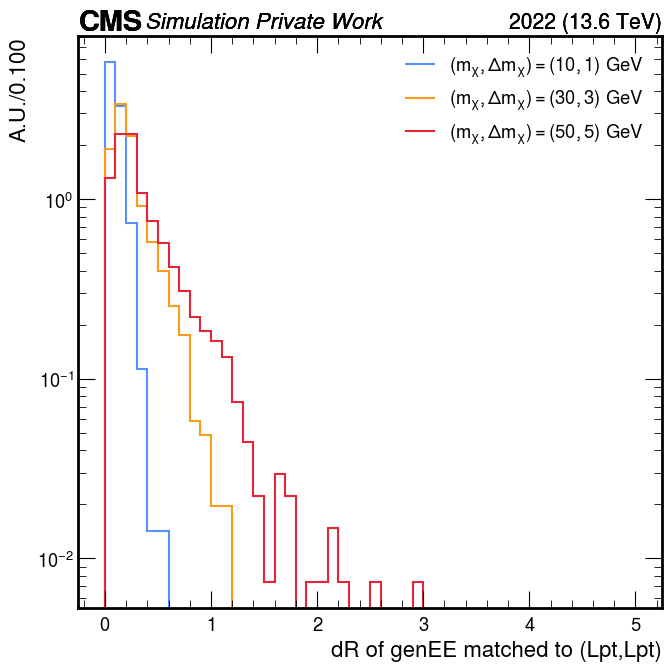

In [9]:
fig, ax = plt.subplots(figsize=(7,7))

plot_dict = {'variable': 'dR_gen_Lpt_Lpt', 'cut': 'cut3', 'year': 2022}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': True,
    'doYerr': False, 
    #'xlabel': "pT of gen electrons(matched to 'R')",  
    'xlabel': "dR of genEE matched to (Lpt,Lpt)",              # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None  ,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2018',
    'outName': f'match_ele_gen_vxy10_m110.png'
}

#signal points
m1s=[10,30,50]
delta =0.1
ctau =10


results_lptlpt = [
    ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict)
    
    for m1 in m1s
]

counts_lptlpt, edges_lptlpt = zip(*results_lptlpt)

counts_lptlpt = np.array(counts_lptlpt)     # shape: (n_m1, n_bins)
edges_lptlpt  = np.array(edges_lptlpt)      # shape: (n_m1, n_edges)


bins_x_lptlpt = (edges_lptlpt[:,:-1] + edges_lptlpt[:,1:])*(0.5)



avg_num_lptlpt = np.mean(counts_lptlpt, axis=0)
print("average=", avg_num_lptlpt)



Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
average= [34.         81.66666667 74.33333333 66.         54.66666667 41.
 24.         13.         13.          7.          5.33333333  3.66666667
  3.33333333  1.          1.33333333  0.33333333  0.33333333  0.33333333
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.33333333
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.        ]


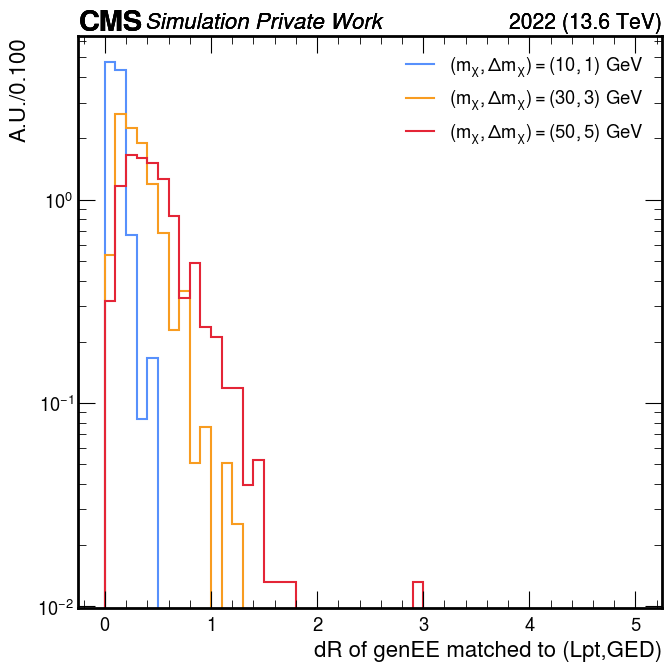

In [10]:
fig, ax = plt.subplots(figsize=(7,7))

plot_dict = {'variable': 'dR_gen_Lpt_GED', 'cut': 'cut3', 'year': 2022}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': True,
    'doYerr': False, 
    #'xlabel': "pT of gen electrons(matched to 'R')",  
    'xlabel': "dR of genEE matched to (Lpt,GED)",              # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None  ,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2018',
    'outName': f'match_ele_gen_vxy10_m110.png'
}

#signal points
m1s=[10,30,50]
delta =0.1
ctau =10


results_lptged = [
    ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict)
    
    for m1 in m1s
]

counts_lptged, edges_lptged = zip(*results_lptged)

counts_lptged = np.array(counts_lptged)     # shape: (n_m1, n_bins)
edges_lptged  = np.array(edges_lptged)      # shape: (n_m1, n_edges)


bins_x_lptged = (edges_lptged[:,:-1] + edges_lptged[:,1:])*(0.5)



avg_num_lptged = np.mean(counts_lptged, axis=0)
print("average=", avg_num_lptged)



Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
average= [16.         45.66666667 52.         84.33333333 60.33333333 37.
 16.33333333 10.33333333  7.66666667  4.          1.66666667  1.
  1.33333333  0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.        ]


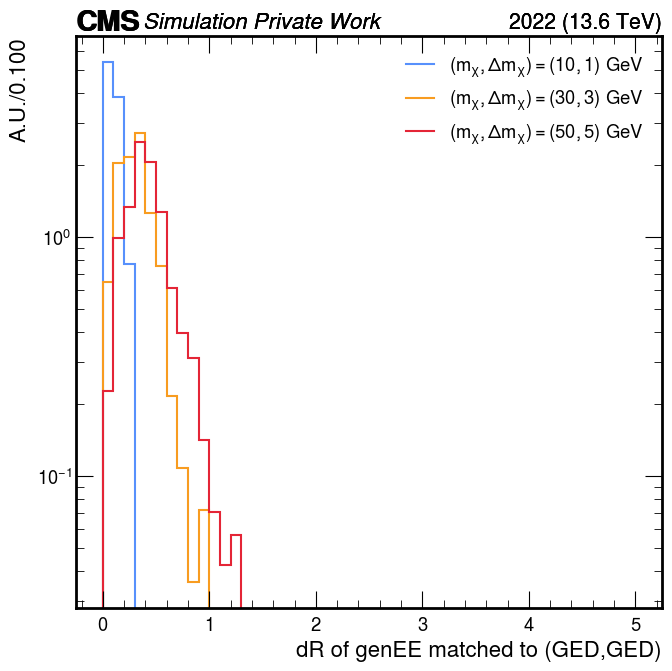

In [11]:
fig, ax = plt.subplots(figsize=(7,7))

plot_dict = {'variable': 'dR_gen_GED_GED', 'cut': 'cut3', 'year': 2022}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': True,
    'doYerr': False, 
    #'xlabel': "pT of gen electrons(matched to 'R')",  
    'xlabel': "dR of genEE matched to (GED,GED)",              # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None  ,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2018',
    'outName': f'match_ele_gen_vxy10_m110.png'
}

#signal points
m1s=[10,30,50]
delta =0.1
ctau =10


results_gedged = [
    ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict)
    
    for m1 in m1s
]

counts_gedged, edges_gedged = zip(*results_gedged)

counts_gedged = np.array(counts_gedged)     # shape: (n_m1, n_bins)
edges_gedged  = np.array(edges_gedged)      # shape: (n_m1, n_edges)


bins_x_gedged = (edges_gedged[:,:-1] + edges_gedged[:,1:])*(0.5)



avg_num_gedged = np.mean(counts_gedged, axis=0)
print("average=", avg_num_gedged)



Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
average= [35.         87.         77.         66.33333333 49.66666667 38.
 24.33333333 17.         14.33333333  7.          2.33333333  4.33333333
  1.66666667  1.66666667  1.66666667  0.          0.          0.33333333
  0.33333333  0.33333333  0.          0.          0.66666667  0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.        ]


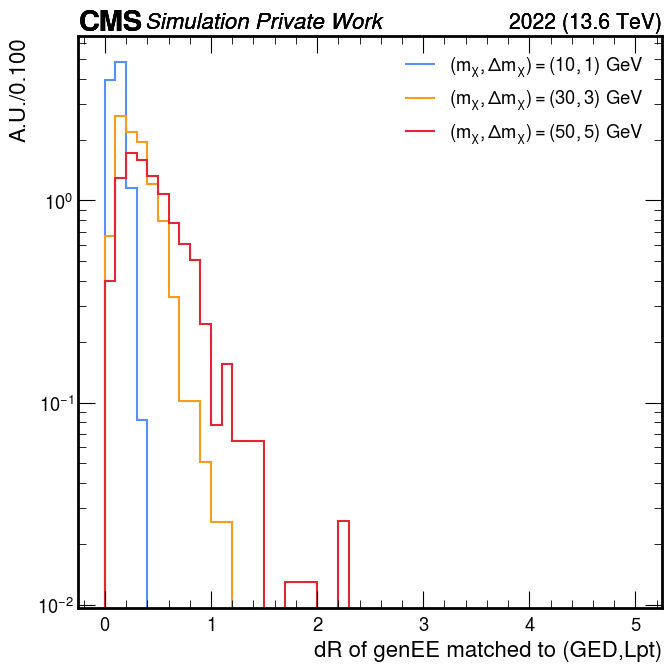

In [13]:
fig, ax = plt.subplots(figsize=(7,7))

plot_dict = {'variable': 'dR_gen_GED_Lpt', 'cut': 'cut3', 'year': 2022}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': True,
    'doYerr': False, 
    #'xlabel': "pT of gen electrons(matched to 'R')",  
    'xlabel': "dR of genEE matched to (GED,Lpt)",              # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None  ,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2018',
    'outName': f'match_ele_gen_vxy10_m110.png'
}

#signal points
m1s=[10,30,50]
delta =0.1
ctau =10


results_gedlpt = [
    ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict)
    
    for m1 in m1s
]

counts_gedlpt, edges_gedlpt = zip(*results_gedlpt)

counts_gedlpt = np.array(counts_gedlpt)     # shape: (n_m1, n_bins)
edges_gedlpt  = np.array(edges_gedlpt)      # shape: (n_m1, n_edges)


bins_x_gedlpt = (edges_gedlpt[:,:-1] + edges_gedlpt[:,1:])*(0.5)



avg_num_gedlpt = np.mean(counts_gedlpt, axis=0)
print("average=", avg_num_gedlpt)



In [22]:
def eff_determine_unc(n, d):
    eff = np.divide(n, d)
    unc = hist.intervals.ratio_uncertainty(n, d, 'efficiency')
    return eff, unc


#Total Eff

#Numerator = number of gen matched to GED + number of gen matched to lpt (xcleaned case)
# Numerator = avg_num_gedged + avg_num_gedlpt + avg_num_lptlpt + avg_num_lptged

Numerator = avg_num_gedged + avg_num_gedlpt + avg_num_lptlpt 


eff_total_rec, unc_eff_rec = eff_determine_unc(Numerator, avg_den)
print ("Total Eff=", eff_total_rec)


Total Eff= [0.43973635 0.4409153  0.39350181 0.35460993 0.32054616 0.27344992
 0.22828508 0.19694868 0.16915423 0.13606911 0.09022556 0.10495627
 0.06291391 0.04867257 0.04060914 0.00578035 0.02666667 0.02484472
 0.00862069 0.0173913  0.00826446 0.02222222 0.04054054 0.
 0.         0.01282051 0.         0.         0.         0.01694915
 0.                nan 0.                nan 0.         0.
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan]


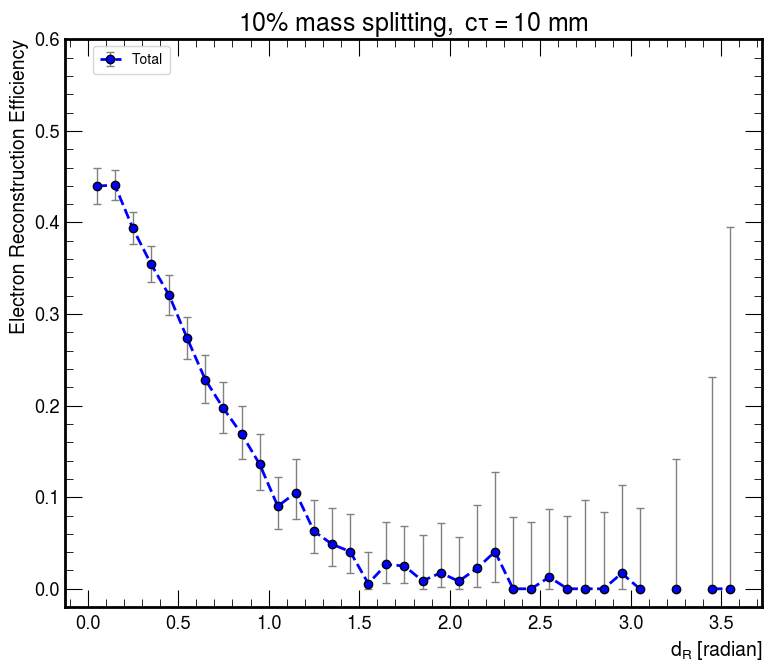

In [23]:
plt.figure(figsize=(8,7))

# plt.errorbar(
#     bins_x_noxcleaned[0,:],
#     efficiency_noxclean,
#     yerr=unc_eff_noxclean,
#     fmt='o-',
#     linewidth=2,
#     markersize=6,
#     color='pink',
#     markeredgecolor='black',
#     ecolor='gray',
#     elinewidth=1,
#     capsize=3,
#     label='Low-pT (No x-cleaning)'
# )

# plt.errorbar(
#     bins_x_xcleaned[0,:],
#     efficiency_xcleaned,
#     yerr=unc_eff_xcleaned,
#     fmt='o-',
#     linewidth=2,
#     markersize=6,
#     color='red',
#     markeredgecolor='black',
#     ecolor='gray',
#     elinewidth=1,
#     capsize=3,
#     label='Low-pT (x-cleaned)'
# )

# plt.errorbar(
#     bins_x_GED[0,:],
#     efficiency_GED,
#     yerr=unc_eff_GED,
#     fmt='o-',
#     linewidth=2,
#     markersize=6,
#     color='orange',
#     markeredgecolor='black',
#     ecolor='gray',
#     elinewidth=1,
#     capsize=3,
#     label='GED'
# )

plt.errorbar(
    bins_x_lptlpt[0,:],
    eff_total_rec,
    yerr=unc_eff_rec,
    fmt='o--',
    linewidth=2,
    markersize=6,
    color='blue',
    markeredgecolor='black',
    ecolor='gray',
    elinewidth=1,
    capsize=3,
    label='Total'
)
# Axis styling
plt.ylim(-0.02, 0.6)
plt.xlabel(r"$d_R$ [radian]", fontsize=14)
plt.ylabel("Electron Reconstruction Efficiency", fontsize=14)



# Grid helps readability
# plt.grid(True, linestyle='--', alpha=0.4)

# Better title formatting


plt.title(
    
    r"$10\%\ \mathrm{mass\ splitting},\ c\tau = 10\ \mathrm{mm}$",
    fontsize=18
)



# plt.legend(fontsize=10, frameon=True, loc='upper left')

plt.legend(
    fontsize=10,
    frameon=True,
    loc='upper left',
    bbox_to_anchor=(0.03, 1)
)

plt.tight_layout()

plt.savefig("L_lxy_ERE.png", dpi=300)